<a href="https://colab.research.google.com/github/srishmath/Generative-AI-Advertisement_generation/blob/main/Dhruva_UI_30_8_latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#TRYING INTEGRATION WITH DYNAMIC PLACEMENT
!pip install --upgrade numpy # Upgrade NumPy to the latest compatible version
!pip install --upgrade numba # Upgrade Numba to the latest version
!pip install --upgrade rembg # Upgrade rembg to the latest version

  Using cached numpy-2.3.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.3.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.2 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >=

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully uninstalled numpy-2.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [1]:
!pip install onnxruntime
!pip install ultralytics


=== Starting Ad Background Generation ===
Product Data: {'gender': 'women', 'baseColour': 'silver', 'usage': 'casual', 'subCategory': 'watches', 'masterCategory': 'accessories', 'year': 2016}
Background Color: pink
Motif: blue flowers
Loading text generation model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Generating background description...
Generated Ad Background Description:
1. Line 1: Soft pink gradient, inspired by the color of a blush.
2. Line 2: Blue flower abstracts, subtle patterns in the design.
3. Line 3: Soft, warm lighting, creating a cozy atmosphere.
4. Line 4: Smooth surface with a hint of gloss.
5. Line 5: Clean, professional ad, enhancing product presentation.

Stable Diffusion Prompt: pink color scheme, abstract background, professional lighting, minimalist design, commercial photography style, clean aesthetic, subtle organic patterns, gradient
Negative Prompt: text, letters, words, logo, watermark, signature, human, person, object, product, realistic, photorealistic, literal, flowers, plants, animals, furniture, interior, room, buildings, watches, accessories, realistic flowers, petals, stems, leaves, garden, nature
Freeing text model memory...
Loading Stable Diffusion pipeline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Generating background image...


  0%|          | 0/50 [00:00<?, ?it/s]

Background generated successfully!


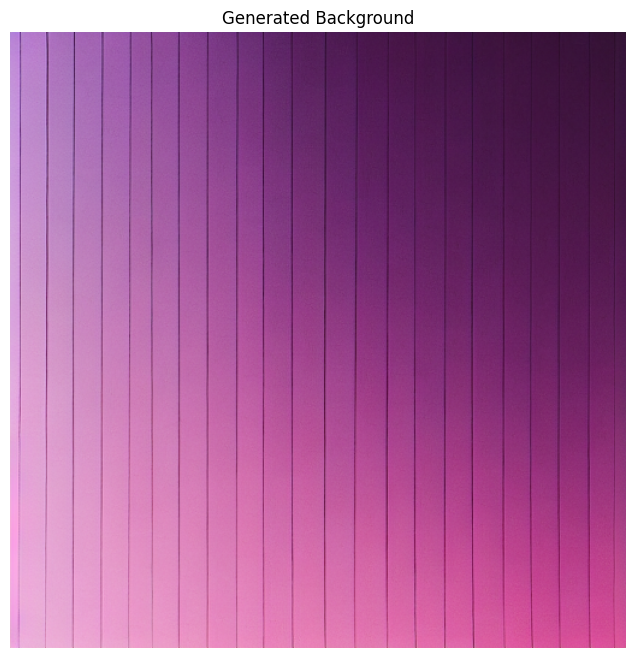


Example 2: Different product
=== Starting Ad Background Generation ===
Product Data: {'gender': 'men', 'color': 'black', 'occasion': 'formal', 'type': 'shoes', 'brand': 'luxury', 'material': 'leather'}
Background Color: deep navy
Motif: geometric patterns
Loading text generation model...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Generating background description...
Generated Ad Background Description:
1. Line 1: Deep navy tones for a formal background
2. Line 2: Abstract geometric shapes and patterns
3. Line 3: Soft lighting and muted colors
4. Line 4: Leather texture adds sophistication
5. Line 5: This clean, minimalist background enhances the product's professional appeal.

Stable Diffusion Prompt: deep navy color scheme, abstract background, professional lighting, minimalist design, commercial photography style, clean aesthetic, geometric patterns, soft
Negative Prompt: text, letters, words, logo, watermark, signature, human, person, object, product, realistic, photorealistic, literal, flowers, plants, animals, furniture, interior, room, buildings, shoes
Freeing text model memory...
Loading Stable Diffusion pipeline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating background image...


  0%|          | 0/50 [00:00<?, ?it/s]

Background generated successfully!


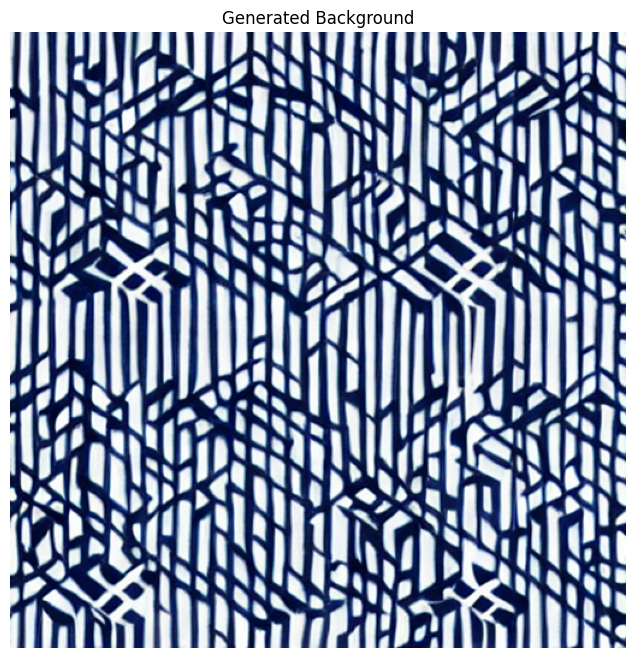

In [2]:
#CELL 1
# ---------------- Install Required Packages ----------------
!pip install -U bitsandbytes transformers diffusers accelerate safetensors

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import gc

# ---------------- Model Name ----------------
model_name = 'filipealmeida/Mistral-7B-Instruct-v0.1-sharded'

# ---------------- Load Quantized Model ----------------
def load_quantized_model(model_name):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        llm_int8_enable_fp32_cpu_offload=True
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    return model

# ---------------- Initialize Tokenizer ----------------
def initialize_tokenizer(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.bos_token_id is None:
        tokenizer.bos_token_id = tokenizer.cls_token_id or 1
    if tokenizer.eos_token_id is None:
        tokenizer.eos_token_id = tokenizer.sep_token_id or 2
    # Fix: Add padding token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer

# ---------------- Build Chat Prompt ----------------
def build_chat_prompt(user_text: str):
    return (
        "You are a meticulous ad-background generator. "
        "Follow ALL constraints exactly. "
        "Output only the 5-line background description.\n\n"
        f"{user_text}"
    )

# ---------------- Generate Response ----------------
def generate_response(prompt_text: str, model, tokenizer):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    chat_prompt = build_chat_prompt(prompt_text)

    inputs = tokenizer(chat_prompt, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

    torch.manual_seed(0)  # reproducibility
    with torch.no_grad():  # Fix: Add no_grad for memory efficiency
        output = model.generate(
            **inputs,
            do_sample=True,  # Fix: Enable sampling for better creativity
            temperature=0.7,  # Fix: Add some temperature for variation
            max_new_tokens=200,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id  # Fix: Add pad_token_id
        )

    # Fix: Only decode the generated part
    generated_tokens = output[0][inputs['input_ids'].shape[1]:]
    text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return text

# ---------------- Enforce Exactly 5 Lines ----------------
def enforce_5_lines(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]

    # If we get one long paragraph, try to split it into sentences
    if len(lines) == 1 and len(lines[0]) > 100:
        # Split by periods and clean up
        sentences = [s.strip() for s in lines[0].split('.') if s.strip()]
        lines = sentences

    # If we still don't have enough lines, split long sentences further
    if len(lines) < 5:
        new_lines = []
        for line in lines:
            if len(line) > 80 and ',' in line:
                # Split by commas for long sentences
                parts = [part.strip() for part in line.split(',') if part.strip()]
                new_lines.extend(parts[:2])  # Take first 2 parts
            else:
                new_lines.append(line)
        lines = new_lines

    # If still not enough, create meaningful background elements based on the content
    if len(lines) < 5:
        base_elements = [
            "Soft gradient transitions create depth and dimension",
            "Subtle lighting enhances the overall composition",
            "Abstract patterns add visual interest without distraction",
            "Professional photography aesthetic maintains focus",
            "Clean minimal design complements the product presentation"
        ]

        # Add meaningful elements to reach 5 lines
        while len(lines) < 5:
            lines.append(base_elements[len(lines) - 1] if len(lines) - 1 < len(base_elements) else base_elements[-1])

    return lines[:5]

# ---------------- Build Product Prompt - Made Dynamic ----------------
def generate_prompt_for_ad_background(data, color, motif):
    # Fix: Make it completely dynamic based on user data
    description_parts = []

    # Dynamically build description from any data provided
    for key, value in data.items():
        if value and str(value).strip():  # Only include non-empty values
            if key.lower() in ['gender']:
                description_parts.append(f"designed for {str(value).lower()}")
            elif key.lower() in ['basecolour', 'color', 'colour']:
                description_parts.append(f"features a {str(value).lower()} color scheme")
            elif key.lower() in ['usage', 'occasion']:
                description_parts.append(f"intended for {str(value).lower()} use")
            elif key.lower() in ['mastercategory', 'category']:
                description_parts.append(f"part of the {str(value).lower()} collection")
            elif key.lower() in ['subcategory', 'type']:
                description_parts.append(f"specifically a {str(value).lower()} item")
            elif key.lower() in ['year', 'season']:
                description_parts.append(f"from {str(value)}")
            else:
                # For any other attributes, include them generically
                description_parts.append(f"has {key.lower()} of {str(value).lower()}")

    # Build product description
    if description_parts:
        product_description = "This product " + ", ".join(description_parts) + "."
    else:
        product_description = "This is a product that needs an advertising background."

    return f"""
Context:
{product_description}

Constraints (MUST follow exactly):
- Background color scheme should be based on {color} tones.
- Design motif should be inspired by {motif} but ONLY as abstract design elements, patterns, or shapes.
- NO realistic objects, people, furniture, or interior/room elements of any kind.
- NO literal representations of {motif} - only abstract interpretations.
- Must be a clean, professional advertising background that complements the product without competing for attention.
- Abstract, minimalist fashion-ad mood only (gradients, soft lighting, reflective surfaces, subtle geometric patterns).
- Background should enhance the product presentation, not distract from it.
- Output EXACTLY 5 separate lines, each on its own line.

Output format (CRITICAL):
- Line 1: [describe the main background color/gradient]
- Line 2: [describe the abstract design elements or patterns]
- Line 3: [describe the lighting and atmosphere]
- Line 4: [describe texture or surface qualities]
- Line 5: [describe overall mood and professional appeal]
- Each line must be separate and concise (under 15 words)
- NO paragraphs, NO combining lines, NO additional text

Begin now:
""".strip()

# ---------------- Convert 5-line text to SD-friendly prompt ----------------
def text_to_visual_prompt(lines, color, motif):
    """
    Converts the 5-line textual background description into a concise
    prompt under 77 tokens for Stable Diffusion - focused on abstract backgrounds.
    """
    # Base elements for professional ad background
    base_elements = [
        f"{color} color scheme",
        "abstract background",
        "professional lighting",
        "minimalist design",
        "commercial photography style",
        "clean aesthetic"
    ]

    # Convert motif to abstract design element
    if "flower" in motif.lower():
        base_elements.append("subtle organic patterns")
    elif "geometric" in motif.lower():
        base_elements.append("geometric patterns")
    elif "wave" in motif.lower():
        base_elements.append("flowing curves")
    else:
        # Generic abstract interpretation
        base_elements.append("abstract design elements")

    # Extract abstract visual elements from generated lines
    abstract_keywords = ['gradient', 'glow', 'shine', 'smooth', 'flowing', 'soft', 'subtle', 'elegant', 'refined']

    for line in lines:
        line_lower = line.lower()
        for keyword in abstract_keywords:
            if keyword in line_lower and keyword not in base_elements:
                base_elements.append(keyword)

    # Keep it focused and under token limit
    visual_prompt = ", ".join(base_elements[:8])
    return visual_prompt

# ---------------- Memory Cleanup Function ----------------
def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ---------------- Main Generation Function ----------------
def generate_ad_background_for_product(product_data, background_color, motif):
    """
    Main function that takes any product data and generates background
    """
    print("=== Starting Ad Background Generation ===")
    print(f"Product Data: {product_data}")
    print(f"Background Color: {background_color}")
    print(f"Motif: {motif}")

    # Load models
    print("Loading text generation model...")
    model = load_quantized_model(model_name)
    tokenizer = initialize_tokenizer(model_name)

    # Generate prompt
    print("Generating background description...")
    ad_prompt = generate_prompt_for_ad_background(product_data, background_color, motif)

    # Generate response
    raw_output = generate_response(ad_prompt, model, tokenizer)
    ad_lines = enforce_5_lines(raw_output)

    print("Generated Ad Background Description:")
    for i, line in enumerate(ad_lines, 1):
        print(f"{i}. {line}")

    # Create negative prompt dynamically - Enhanced to prevent literal objects
    excluded_terms = []
    for key, value in product_data.items():
        if key.lower() in ['subcategory', 'mastercategory', 'category', 'type'] and value:
            excluded_terms.append(str(value).lower())

    # Enhanced negative prompt to prevent literal interpretations
    negative_prompt = "text, letters, words, logo, watermark, signature, human, person, object, product, realistic, photorealistic, literal, flowers, plants, animals, furniture, interior, room, buildings"
    if excluded_terms:
        negative_prompt += ", " + ", ".join(excluded_terms)

    # Add motif-specific negatives to prevent literal interpretation
    if "flower" in motif.lower():
        negative_prompt += ", realistic flowers, petals, stems, leaves, garden, nature"
    elif "wave" in motif.lower():
        negative_prompt += ", ocean, water, sea, realistic waves"
    elif "star" in motif.lower():
        negative_prompt += ", realistic stars, night sky, space"

    # Convert to SD prompt
    sd_prompt = text_to_visual_prompt(ad_lines, background_color, motif)
    print(f"\nStable Diffusion Prompt: {sd_prompt}")
    print(f"Negative Prompt: {negative_prompt}")

    # Free text model memory
    print("Freeing text model memory...")
    model.cpu()
    del model
    cleanup_memory()

    # Load Stable Diffusion
    print("Loading Stable Diffusion pipeline...")
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")

    # Generate image
    print("Generating background image...")
    pipe.safety_checker = None  # optional: disable safety check if safe

    background_image = pipe(
        prompt=sd_prompt,
        negative_prompt=negative_prompt,
        guidance_scale=8.0,
        num_inference_steps=50
    ).images[0]

    # Save and display
    background_image.save("generated_background.png")
    print("Background generated successfully!")

    plt.figure(figsize=(10, 8))
    plt.imshow(background_image)
    plt.axis("off")
    plt.title("Generated Background")
    plt.show()

    return background_image, ad_lines, sd_prompt

# ---------------- Example Usage ----------------
if __name__ == "__main__":
    # Example 1: Your original watch data
    product_data = {
        "gender": "women",
        "baseColour": "silver",
        "usage": "casual",
        "subCategory": "watches",
        "masterCategory": "accessories",
        "year": 2016
    }

    generate_ad_background_for_product(
        product_data=product_data,
        background_color="pink",
        motif="blue flowers"
    )

    # Example 2: Different product to show flexibility
    print("\n" + "="*60)
    print("Example 2: Different product")

    product_data_2 = {
        "gender": "men",
        "color": "black",
        "occasion": "formal",
        "type": "shoes",
        "brand": "luxury",
        "material": "leather"
    }

    generate_ad_background_for_product(
        product_data=product_data_2,
        background_color="deep navy",
        motif="geometric patterns"
    )

Example 1: Cylinder Pedestal
=== Starting Ad Background Generation with Pure White Pedestal ===
=== Starting Ad Background Generation ===
Product Data: {'gender': 'women', 'baseColour': 'silver', 'usage': 'casual', 'subCategory': 'watches', 'masterCategory': 'accessories', 'year': 2016}
Background Color: turquoise
Motif: geometric circles
Loading text generation model...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Generating background description...
Generated Ad Background Description:
1. Line 1: Turquoise gradient with silver accents
2. Line 2: Abstract geometric shapes and circles
3. Line 3: Soft, ethereal lighting
4. Line 4: Smooth, reflective surface
5. Line 5: Professional, minimalist fashion ad mood

Stable Diffusion Prompt: turquoise color scheme, abstract background, professional lighting, minimalist design, commercial photography style, clean aesthetic, geometric patterns, gradient
Negative Prompt: text, letters, words, logo, watermark, signature, human, person, object, product, realistic, photorealistic, literal, flowers, plants, animals, furniture, interior, room, buildings, watches, accessories
Freeing text model memory...
Loading Stable Diffusion pipeline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating background image...


  0%|          | 0/50 [00:00<?, ?it/s]

Background generated successfully!


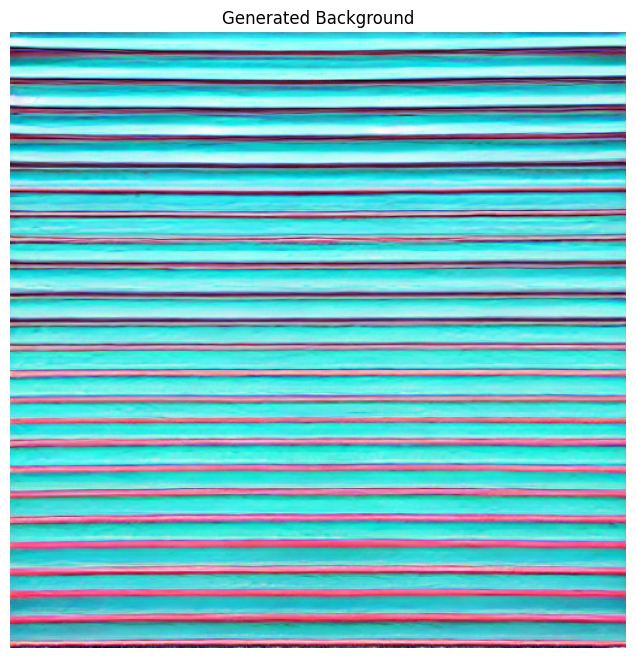

Adding solid white cylinder pedestal...
Platform metadata saved to platform_metadata.json
Pure white pedestal generated successfully!


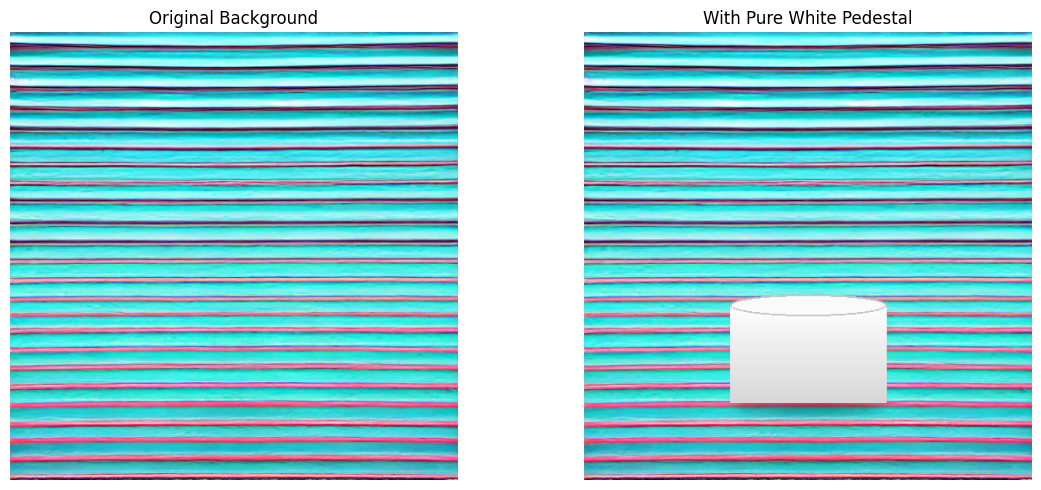

In [3]:

import matplotlib.pyplot as plt
import json


from PIL import Image, ImageDraw, ImageFilter

def create_cylindrical_pedestal(width, height, pedestal_color="white", shadow_intensity=0.3):
    """Creates a more realistic cylindrical pedestal with gradient and soft shadow."""
    img = Image.new('RGBA', (width, height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(img)

    pedestal_width = int(width * 0.35)
    pedestal_height = int(height * 0.22)

    center_x = width // 2
    center_y = int(height * 0.72)

    # Top ellipse
    top_ellipse_coords = [
        center_x - pedestal_width // 2,
        center_y - pedestal_height // 2 - 12,
        center_x + pedestal_width // 2,
        center_y - pedestal_height // 2 + 12
    ]

    # Gradient fill (vertical)
    body = Image.new("RGBA", (pedestal_width, pedestal_height), (0, 0, 0, 0))
    body_draw = ImageDraw.Draw(body)
    for y in range(pedestal_height):
        shade = int(255 - (y / pedestal_height) * 40)  # subtle darker bottom
        body_draw.line([(0, y), (pedestal_width, y)], fill=(shade, shade, shade, 255))
    img.paste(body, (center_x - pedestal_width // 2, center_y - pedestal_height // 2), body)

    # Top ellipse with subtle highlight
    draw.ellipse(top_ellipse_coords, fill=(250, 250, 250, 255), outline=(200, 200, 200, 255), width=2)

    # Soft shadow under pedestal
    shadow = Image.new("RGBA", img.size, (0, 0, 0, 0))
    shadow_draw = ImageDraw.Draw(shadow)
    shadow_ellipse = [
        center_x - pedestal_width // 2,
        center_y + pedestal_height // 2 - 5,
        center_x + pedestal_width // 2,
        center_y + pedestal_height // 2 + 10
    ]
    shadow_draw.ellipse(shadow_ellipse, fill=(0, 0, 0, int(255 * shadow_intensity)))
    shadow = shadow.filter(ImageFilter.GaussianBlur(6))
    img = Image.alpha_composite(shadow, img)

    # Metadata stays the same
    img.platform_info = {
        'center': (center_x, center_y - pedestal_height // 2),
        'top_surface': {
            'bbox': top_ellipse_coords,
            'width': pedestal_width,
            'height': 24
        },
        'type': 'cylindrical_pedestal'
    }

    return img


def create_cube_pedestal(width, height, pedestal_color="white", perspective_angle=15):
    """Creates a cube pedestal with metadata for placement."""
    img = Image.new('RGBA', (width, height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(img)

    cube_size = int(min(width, height) * 0.22)
    center_x = width // 2
    center_y = int(height * 0.75)
    offset = int(cube_size * 0.3)

    top_color = (255, 255, 255, 255)
    front_color = (255, 255, 255, 255)
    side_color = (245, 245, 245, 255)
    outline_color = (220, 220, 220, 255)

    # Shadow for realism
    shadow_points = [
        (center_x - cube_size // 2 + 8, center_y + cube_size // 2 + 8),
        (center_x + cube_size // 2 + 8, center_y + cube_size // 2 + 8),
        (center_x + cube_size // 2 + offset + 8, center_y + cube_size // 2 - offset + 8),
        (center_x - cube_size // 2 + offset + 8, center_y + cube_size // 2 - offset + 8)
    ]
    draw.polygon(shadow_points, fill=(0, 0, 0, 80))

    # Cube faces
    front_points = [
        (center_x - cube_size // 2, center_y - cube_size // 2),
        (center_x + cube_size // 2, center_y - cube_size // 2),
        (center_x + cube_size // 2, center_y + cube_size // 2),
        (center_x - cube_size // 2, center_y + cube_size // 2)
    ]
    side_points = [
        (center_x + cube_size // 2, center_y - cube_size // 2),
        (center_x + cube_size // 2 + offset, center_y - cube_size // 2 - offset),
        (center_x + cube_size // 2 + offset, center_y + cube_size // 2 - offset),
        (center_x + cube_size // 2, center_y + cube_size // 2)
    ]
    top_points = [
        (center_x - cube_size // 2, center_y - cube_size // 2),
        (center_x + cube_size // 2, center_y - cube_size // 2),
        (center_x + cube_size // 2 + offset, center_y - cube_size // 2 - offset),
        (center_x - cube_size // 2 + offset, center_y - cube_size // 2 - offset)
    ]

    # Draw cube
    draw.polygon(side_points, fill=side_color, outline=outline_color)
    draw.polygon(top_points, fill=top_color, outline=outline_color)
    draw.polygon(front_points, fill=front_color, outline=outline_color)

    # Metadata for placement
    img.platform_info = {
        'center': (center_x, center_y - cube_size // 2),
        'top_surface': {
            'points': top_points,
            'width': cube_size + offset,
            'height': cube_size // 2
        },
        'type': 'cube_pedestal'
    }

    return img


def add_pedestal_to_background(background_image, pedestal_type="cylinder", pedestal_color="white", pedestal_style="modern"):
    bg_img = background_image.copy() if hasattr(background_image, 'size') else Image.fromarray(background_image)
    width, height = bg_img.size

    pedestal_img = create_cylindrical_pedestal(width, height, pedestal_color) if pedestal_type == "cylinder" \
        else create_cube_pedestal(width, height, pedestal_color)

    final_img = Image.alpha_composite(bg_img.convert('RGBA'), pedestal_img).convert('RGB')

    if hasattr(pedestal_img, 'platform_info'):
        final_img.platform_info = pedestal_img.platform_info

    return final_img


def get_platform_placement_info(image_with_pedestal):
    """Returns clean metadata for consistent placement."""
    if hasattr(image_with_pedestal, 'platform_info'):
        platform_info = image_with_pedestal.platform_info
        return {
            'center': platform_info['center'],
            'top_surface': platform_info['top_surface'],
            'type': f"generated_{platform_info['type']}"
        }
    return None


def generate_ad_background_with_pedestal(product_data, background_color, motif,
                                         pedestal_type="cylinder", pedestal_color="white",
                                         pedestal_style="modern", show_guide=True):
    print("=== Starting Ad Background Generation with Pure White Pedestal ===")

    # Use background generator from Cell 1
    background_image, ad_lines, sd_prompt = generate_ad_background_for_product(
        product_data, background_color, motif
    )

    # Add pedestal
    print(f"Adding solid white {pedestal_type} pedestal...")
    background_with_pedestal = add_pedestal_to_background(
        background_image, pedestal_type, pedestal_color, pedestal_style
    )

    background_with_pedestal.save("background_with_solid_pedestal.png")

    # Save metadata
    platform_info = get_platform_placement_info(background_with_pedestal)
    if platform_info:
        with open("platform_metadata.json", "w") as f:
            json.dump(platform_info, f, indent=2)
        print("Platform metadata saved to platform_metadata.json")

    print("Pure white pedestal generated successfully!")

    if show_guide:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(background_image)
        axes[0].set_title("Original Background")
        axes[0].axis("off")

        axes[1].imshow(background_with_pedestal)
        axes[1].set_title("With Pure White Pedestal")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return background_with_pedestal, ad_lines, sd_prompt


# ---------------- Usage Examples ----------------
def example_usage():
    """
    Examples of how to use the enhanced function
    """
    # Your original product data
    product_data = {
        "gender": "women",
        "baseColour": "silver",
        "usage": "casual",
        "subCategory": "watches",
        "masterCategory": "accessories",
        "year": 2016
    }

    # Example 1: Cylinder pedestal (like your reference image)
    print("Example 1: Cylinder Pedestal")
    generate_ad_background_with_pedestal(
        product_data=product_data,
        background_color="turquoise",  # To match your reference image
        motif="geometric circles",
        pedestal_type="cylinder",
        pedestal_color="white",
        pedestal_style="modern"
    )

    # # Example 2: Geometric pedestal
    # print("\n" + "="*50)
    # print("Example 2: Geometric Pedestal")
    # generate_ad_background_with_pedestal(
    #     product_data=product_data,
    #     background_color="pink",
    #     motif="blue flowers",
    #     pedestal_type="geometric",
    #     pedestal_color="glass",
    #     pedestal_style="modern"
    # )

# To integrate with your existing code, simply replace your final function call with:
# generate_ad_background_with_pedestal(product_data, background_color, motif)

if __name__ == "__main__":
    example_usage()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.2 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which i

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 77.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully uninstalled numpy-2.3.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0,

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 5.2 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.4 MB/s eta 0:00:00


In [4]:
from PIL import Image

def crop_to_content(img: Image.Image) -> Image.Image:
    """
    Crops an RGBA image to the bounding box of non-transparent pixels.
    """
    if img.mode != "RGBA":
        img = img.convert("RGBA")

    # Get alpha channel
    alpha = img.getchannel("A")

    # Get bounding box of non-transparent region
    bbox = alpha.getbbox()
    if bbox:
        img = img.crop(bbox)
    return img


📂 Loaded platform metadata: {'center': [256, 312], 'top_surface': {'bbox': [167, 300, 345, 324], 'width': 179, 'height': 24}, 'type': 'generated_cylindrical_pedestal'}


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-9-1 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


🚀 Starting platform detection process...
📏 Product resized to: 160x180 pixels
🖼️ Background size: (512, 512)
🔍 Analyzing image for 3D rendered platforms...
📊 White regions detected: 23608 pixels
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 21440.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour a

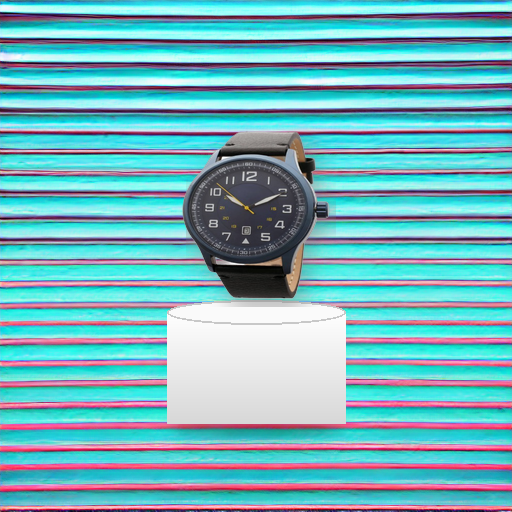

🎯 SUCCESS: Product placed on generated_cylindrical_pedestal platform!
✅ Final ad saved with text overlay!


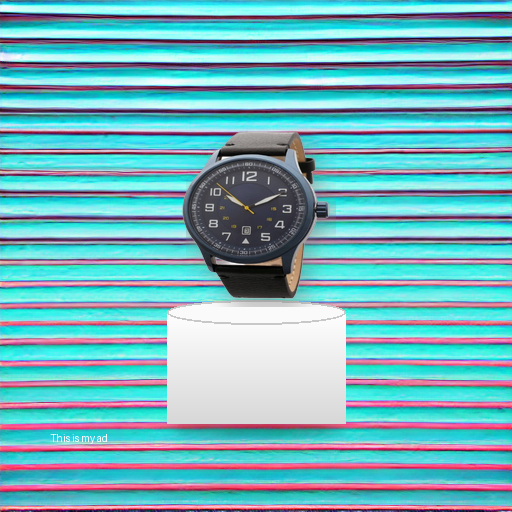

In [5]:
#version 4 - Multi-Color Platform Detection

from PIL import Image, ImageDraw, ImageStat, ImageFilter, ImageEnhance
import numpy as np
import cv2
import random
from rembg import remove
from IPython.display import display
import torch
from scipy import ndimage
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import json
import os

# Load platform metadata if available
metadata_path = "platform_metadata.json"
platform_metadata = None
if os.path.exists(metadata_path):
    with open(metadata_path, "r") as f:
        platform_metadata = json.load(f)
    print(f"📂 Loaded platform metadata: {platform_metadata}")

class PlatformSurfaceDetector:
    def __init__(self):
        self.model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

    # Helper function to crop to content


    def detect_rendered_platforms(self, image):
        """Specialized detection for 3D rendered platforms - now supports multiple colors"""
        cv_image = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
        h, w = cv_image.shape[:2]

        print("🔍 Analyzing image for 3D rendered platforms...")

        platforms = []
        hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)

        # MAIN FIX: Multiple color ranges for different platform types
        color_ranges = {
            'white': ([0, 0, 180], [180, 30, 255]),
            'green': ([35, 40, 100], [85, 255, 255]),
            'blue': ([100, 50, 100], [130, 255, 255]),
            'brown': ([8, 50, 80], [25, 255, 200]),
            'gray': ([0, 0, 60], [180, 50, 180]),
            'cream': ([15, 20, 150], [35, 80, 255]),
            'pink': ([140, 30, 150], [170, 100, 255])
        }

        # Method 1: Multi-color platform detection
        for color_name, (lower, upper) in color_ranges.items():
            lower = np.array(lower)
            upper = np.array(upper)
            color_mask = cv2.inRange(hsv, lower, upper)

            print(f"📊 {color_name.capitalize()} regions detected: {np.sum(color_mask > 0)} pixels")

            contours, _ = cv2.findContours(color_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                area = cv2.contourArea(contour)
                print(f"   {color_name} contour area: {area}")

                if area > 800:
                    x, y, w_rect, h_rect = cv2.boundingRect(contour)
                    aspect_ratio = w_rect / h_rect
                    if 0.7 < aspect_ratio < 1.4:
                        if len(contour) >= 5:
                            ellipse = cv2.fitEllipse(contour)
                            center = (int(ellipse[0][0]), int(ellipse[0][1]))
                            axes = (int(ellipse[1][0]/2), int(ellipse[1][1]/2))

                            platforms.append({
                                'center': center,
                                'axes': axes,
                                'bbox': (x, y, x + w_rect, y + h_rect),
                                'type': f'rendered_platform_{color_name}',
                                'area': area,
                                'contour': contour,
                                'color': color_name
                            })
                            print(f"✅ Found {color_name} platform at {center} with size {axes}")

        # Method 2: Edge-based circular detection
        blurred = cv2.GaussianBlur(gray, (5, 5), 1)
        circles = cv2.HoughCircles(
            blurred,
            cv2.HOUGH_GRADIENT,
            dp=1,
            minDist=30,
            param1=30,
            param2=20,
            minRadius=15,
            maxRadius=min(w, h) // 3
        )

        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            print(f"🔵 HoughCircles found {len(circles)} circles")

            for (x, y, r) in circles:
                if self.validate_rendered_platform_improved(cv_image, x, y, r):
                    platforms.append({
                        'center': (x, y),
                        'radius': r,
                        'bbox': (x-r, y-r, x+r, y+r),
                        'type': 'circular_platform',
                        'area': np.pi * r * r
                    })
                    print(f"✅ Validated circular platform at ({x}, {y}) radius {r}")

        template_platforms = self.detect_by_brightness_patterns_improved(cv_image)
        platforms.extend(template_platforms)

        return platforms

    def validate_rendered_platform_improved(self, image, center_x, center_y, radius):
        h, w = image.shape[:2]
        if (center_x - radius < 0 or center_x + radius >= w or
            center_y - radius < 0 or center_y + radius >= h):
            return False

        roi = image[max(0, center_y-radius):min(h, center_y+radius),
                   max(0, center_x-radius):min(w, center_x+radius)]

        if roi.size == 0:
            return False

        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        variance = np.var(roi_gray)
        if variance < 2000:
            padding = radius // 2
            surround_roi = image[max(0, center_y-radius-padding):min(h, center_y+radius+padding),
                               max(0, center_x-radius-padding):min(w, center_x+radius+padding)]

            if surround_roi.size > 0:
                surround_gray = cv2.cvtColor(surround_roi, cv2.COLOR_BGR2GRAY)
                roi_mean = np.mean(roi_gray)
                surround_mean = np.mean(surround_gray)

                if abs(roi_mean - surround_mean) > 15:
                    print(f"   Platform validated - variance: {variance:.1f}, contrast: {abs(roi_mean - surround_mean):.1f}")
                    return True
        return False

    def detect_by_brightness_patterns_improved(self, cv_image):
        gray = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
        platforms = []
        percentiles = [85, 75, 65, 35, 25, 15]

        for percentile in percentiles:
            if percentile > 50:
                threshold = np.percentile(gray, percentile)
                mask = gray > threshold
                region_type = f'bright_{percentile}'
            else:
                threshold = np.percentile(gray, percentile)
                mask = gray < threshold
                region_type = f'dark_{percentile}'

            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
                mask.astype(np.uint8), connectivity=8
            )

            for i in range(1, num_labels):
                area = stats[i, cv2.CC_STAT_AREA]
                if area > 500:
                    x, y, w, h = (stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP],
                                  stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT])
                    aspect_ratio = w / h
                    if 0.5 < aspect_ratio < 2.0:
                        center_x = int(centroids[i][0])
                        center_y = int(centroids[i][1])
                        roi = gray[y:y+h, x:x+w]
                        if roi.size > 0 and np.var(roi) < 1500:
                            platforms.append({
                                'center': (center_x, center_y),
                                'bbox': (x, y, x + w, y + h),
                                'type': f'brightness_platform_{region_type}',
                                'area': area,
                                'aspect_ratio': aspect_ratio
                            })
                            print(f"✅ {region_type} platform found at ({center_x}, {center_y})")
        return platforms

    def find_best_platform_placement(self, platforms, product_size, image_size):
        if not platforms:
            return None
        print(f"🎯 Evaluating {len(platforms)} platforms for placement...")
        best_platform = None
        best_score = -1
        img_width, img_height = image_size
        product_width, product_height = product_size

        for i, platform in enumerate(platforms):
            score = 0
            if platform['type'] == 'circular_platform':
                radius = platform.get('radius', 50)
                if product_width < radius * 2.5 and product_height < radius * 2.5:
                    score += 1.5
            else:
                x1, y1, x2, y2 = platform['bbox']
                platform_width = x2 - x1
                platform_height = y2 - y1
                if (product_width < platform_width * 1.2 and
                    product_height < platform_height * 1.2):
                    score += 1.5

            center_x, center_y = platform['center']
            if 0.2 * img_height < center_y < 0.8 * img_height:
                score += 1.0

            area = platform.get('area', 0)
            if area > 1000:
                score += 0.5

            platform_type = platform['type']
            if 'rendered_platform' in platform_type:
                score += 0.8
            elif platform_type == 'circular_platform':
                score += 0.9
            elif 'brightness_platform_bright' in platform_type:
                score += 0.7
            elif 'brightness_platform_dark' in platform_type:
                score += 0.5

            print(f"   Platform {i+1} ({platform['type']}): score = {score:.2f}")
            if score > best_score:
                best_score = score
                best_platform = platform

        print(f"🏆 Selected platform with score: {best_score:.2f}")
        return best_platform

    def calculate_product_position_on_platform(self, platform, product_size, image_size):
        product_width, product_height = product_size
        center_x, center_y = platform['center']
        x = center_x - product_width // 2
        y = center_y - product_height // 2
        img_width, img_height = image_size
        x = max(0, min(x, img_width - product_width))
        y = max(0, min(y, img_height - product_height))
        return (int(x), int(y))

    def create_platform_aware_shadow(self, product_image, platform, product_position):
        shadow = Image.new("RGBA", product_image.size, (0, 0, 0, 0))
        mask = product_image.split()[3]

        if platform['type'] == 'circular_platform':
            blur_radius = 15
            opacity = 0.25
            offset_x, offset_y = 4, 6
        elif 'rendered_platform' in platform['type']:
            blur_radius = 12
            opacity = 0.3
            offset_x, offset_y = 3, 5
        else:
            blur_radius = 10
            opacity = 0.35
            offset_x, offset_y = 5, 7

        shadow_pixels = shadow.load()
        mask_pixels = mask.load()
        for y in range(shadow.height):
            for x in range(shadow.width):
                if mask_pixels[x, y] > 0:
                    shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * opacity))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        return shadow, (offset_x, offset_y)

    def process_with_platform_detection(self, product_path, background_path):
        print("🚀 Starting platform detection process...")

        product_with_bg = Image.open(product_path).convert("RGB")
        product_no_bg = remove(product_with_bg)
        product_no_bg = crop_to_content(product_no_bg)

        # Resize product to fixed 160x180 pixels
        product_no_bg = product_no_bg.resize((150, 170), Image.LANCZOS)
        print(f"📏 Product resized to: 160x180 pixels")

        background_image = Image.open(background_path).convert("RGBA")
        print(f"🖼️ Background size: {background_image.size}")

        detected_platforms = self.detect_rendered_platforms(background_image)
        print(f"📊 Total platforms detected: {len(detected_platforms)}")

        best_platform = None
        product_position = None

        if platform_metadata:
            print("🎯 Using platform metadata for placement")
            top_surface = platform_metadata.get("top_surface", {})
            if "bbox" in top_surface:
                x1, y1, x2, y2 = top_surface["bbox"]
                surface_center = ((x1 + x2) // 2, (y1 + y2) // 2)
                best_platform = {
                    "center": surface_center,
                    "bbox": (x1, y1, x2, y2),
                    "type": platform_metadata.get("type", "metadata_platform"),
                    "area": top_surface.get("width", 0) * top_surface.get("height", 0)
                }
                product_x = surface_center[0] - product_no_bg.width // 2
                product_y = y1 - product_no_bg.height
                product_position = (product_x, product_y)
            else:
                best_platform = {
                    "center": tuple(platform_metadata["center"]),
                    "bbox": platform_metadata.get("bbox"),
                    "type": platform_metadata.get("type", "metadata_platform"),
                    "area": 0
                }
                cx, cy = best_platform["center"]
                product_x = cx - product_no_bg.width // 2
                product_y = cy - product_no_bg.height // 2
                product_position = (product_x, product_y)

        if not best_platform and detected_platforms:
            best_platform = self.find_best_platform_placement(
                detected_platforms, product_no_bg.size, background_image.size
            )
            if best_platform:
                product_position = self.calculate_product_position_on_platform(
                    best_platform, product_no_bg.size, background_image.size
                )

        if best_platform:
            print(f"✅ Selected {best_platform['type']} platform at {best_platform['center']}")
            product_shadow, shadow_offset = self.create_platform_aware_shadow(
                product_no_bg, best_platform, product_position
            )
        else:
            print("⚠️ No suitable platform found, using center placement")
            product_position = (
                (background_image.width - product_no_bg.width) // 2,
                (background_image.height - product_no_bg.height) // 2
            )
            shadow = Image.new("RGBA", product_no_bg.size, (0, 0, 0, 0))
            mask = product_no_bg.split()[3]
            shadow_pixels = shadow.load()
            mask_pixels = mask.load()
            for y in range(shadow.height):
                for x in range(shadow.width):
                    if mask_pixels[x, y] > 0:
                        shadow_pixels[x, y] = (0, 0, 0, int(mask_pixels[x, y] * 0.4))
            product_shadow = shadow.filter(ImageFilter.GaussianBlur(radius=10))
            shadow_offset = (5, 5)

        final_image = background_image.copy()
        shadow_position = (
            product_position[0] + shadow_offset[0],
            product_position[1] + shadow_offset[1]
        )
        final_image.paste(product_shadow, shadow_position, product_shadow)
        final_image.paste(product_no_bg, product_position, product_no_bg)

        print(f"🎨 Final placement at: {product_position}")
        return final_image, detected_platforms, best_platform


# Usage
detector = PlatformSurfaceDetector()
final_image, detected_platforms, selected_platform = detector.process_with_platform_detection(
    "/content/watch.jpeg",
    "/content/background_with_solid_pedestal.png"
)



final_image.save("/content/platform_placement_result.png")
display(final_image)



if selected_platform:
    print(f"🎯 SUCCESS: Product placed on {selected_platform['type']} platform!")
else:
    print("❌ No platform detected - check detection parameters")


from PIL import ImageFont

# After your final_image creation
draw = ImageDraw.Draw(final_image)

# Choose font & size (use default if no font file available)
try:
    font = ImageFont.truetype("arial.ttf", 40)  # you can upload a .ttf file if needed
except:
    font = ImageFont.load_default()

# Define text and position
ad_text = "This is my ad"
text_position = (50, final_image.height - 80)  # bottom-left corner
text_color = (255, 255, 255, 255)  # white

# Draw text on final image
draw.text(text_position, ad_text, font=font, fill=text_color)

# Save the final image with text
final_image.save("/content/platform_placement_result_with_text.png")

print("✅ Final ad saved with text overlay!")
display(final_image)



In [6]:
from PIL import Image, ImageDraw, ImageFont

# Load your final image
image = Image.open("/content/platform_placement_result_with_text.png")  # change to your image path

# Create a drawing context
draw = ImageDraw.Draw(image)

# Text to add
text = "This is my ad"

# Try loading a TTF font, fallback to default if not available
try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 1000)  # Kaggle/Colab usually has this
except OSError:
    font = ImageFont.load_default()

# Get image size
W, H = image.size

# Get text size
bbox = draw.textbbox((0, 0), text, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]

# Position: centered at bottom
x = (W - text_width) // 2
y = H - text_height - 20  # 20px margin from bottom

# Draw text
draw.text((x, y), text, font=font, fill="black")

# Save or display result
image.save("final_with_text2.png")
image.show()


In [8]:
# ===== Cell 5 — Gradio UI (Upload product image) =====
!pip -q install gradio

import gradio as gr
from PIL import Image, ImageDraw, ImageFont
import os, time, json

def run_pipeline(product_img, background_color, motif, pedestal_type,
                 gender, baseColour, usage, subCategory, masterCategory, year):
    """
    Thin UI wrapper that:
      1) Saves the uploaded product
      2) Generates the background+pedestal via your existing function
      3) Runs your PlatformSurfaceDetector to place the product
      4) Adds ad text at the bottom
      5) Saves final as PNG and returns the PIL image + file path
    """
    try:
        if product_img is None:
            return None, None, "Please upload a product image."

        # 1) Save uploaded product to disk
        os.makedirs("/content", exist_ok=True)
        uploaded_path = "/content/uploaded_product.png"
        product_img.save(uploaded_path)

        # 2) Build product data from UI fields
        product_data = {}
        if gender: product_data["gender"] = gender
        if baseColour: product_data["baseColour"] = baseColour
        if usage: product_data["usage"] = usage
        if subCategory: product_data["subCategory"] = subCategory
        if masterCategory: product_data["masterCategory"] = masterCategory
        if year:
            try:
                product_data["year"] = int(year)
            except:
                pass  # ignore invalid year

        # 3) Generate background with pedestal
        _bg_img, _ad_lines, _sd_prompt = generate_ad_background_with_pedestal(
            product_data=product_data,
            background_color=background_color,
            motif=motif,
            pedestal_type=pedestal_type if pedestal_type in ["cylinder", "cube"] else "cylinder",
            pedestal_color="white",
            pedestal_style="modern",
            show_guide=False
        )

        background_path = "/content/background_with_solid_pedestal.png"
        if not os.path.exists(background_path):
            return None, None, "Background image was not created. Please check previous cells."

        # 4) Place product
        detector = PlatformSurfaceDetector()
        final_image, detected_platforms, selected_platform = detector.process_with_platform_detection(
            uploaded_path,
            background_path
        )

        # === New: Add text at bottom ===
        draw = ImageDraw.Draw(final_image)
        text = "This is my ad"

        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 80)
        except OSError:
            font = ImageFont.load_default()

        W, H = final_image.size
        bbox = draw.textbbox((0, 0), text, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        x = (W - text_width) // 2
        y = H - text_height - 20
        draw.text((x, y), text, font=font, fill="black")

        # Save to temp file
        ts = int(time.time())
        out_path = f"/content/ad_{ts}.png"
        final_image.save(out_path, format="PNG")

        status = "✅ Ad generated successfully."
        if selected_platform:
            status += f" Placed on {selected_platform.get('type', 'platform')}."
        else:
            status += " (No platform detected; centered placement used.)"

        return final_image, out_path, status

    except Exception as e:
        return None, None, f"❌ Error: {str(e)}"


with gr.Blocks(theme=gr.themes.Soft(primary_hue="violet", secondary_hue="cyan")) as demo:
    gr.Markdown(
        """
        <div style="text-align:center">
          <h1>🎨 Generative AI Ad Creator</h1>
          <p>Create a stylish ad by generating a background + pedestal and placing your product automatically.</p>
        </div>
        """,
    )

    with gr.Row():
        with gr.Column(scale=1):
            product_input = gr.Image(type="pil", label="📦 Upload Product Image (PNG/JPG)")

            with gr.Accordion("🎛️ Product Attributes (optional)", open=False):
                gender = gr.Dropdown(choices=["men", "women", "unisex"], label="Gender", value=None)
                baseColour = gr.Textbox(label="Base Colour", placeholder="e.g. silver, black")
                usage = gr.Textbox(label="Usage", placeholder="e.g. casual, formal")
                subCategory = gr.Textbox(label="Sub Category", placeholder="e.g. watches, shoes")
                masterCategory = gr.Textbox(label="Master Category", placeholder="e.g. accessories, footwear")
                year = gr.Textbox(label="Year", placeholder="e.g. 2016")

            with gr.Accordion("🎨 Background Style", open=True):
                background_color = gr.Textbox(label="Background Color", value="turquoise")
                motif = gr.Textbox(label="Motif (abstract inspiration)", value="geometric circles")
                pedestal_type = gr.Radio(["cylinder", "cube"], value="cylinder", label="Pedestal Type")

            generate_btn = gr.Button("🚀 Generate Ad", variant="primary")

        with gr.Column(scale=1):
            output_img = gr.Image(type="pil", label="🎉 Generated Ad", interactive=False)
            download_file = gr.File(label="⬇️ Download PNG", file_types=[".png"])
            status_box = gr.HTML()

    generate_btn.click(
        fn=run_pipeline,
        inputs=[product_input, background_color, motif, pedestal_type,
                gender, baseColour, usage, subCategory, masterCategory, year],
        outputs=[output_img, download_file, status_box]
    )

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7dcebf9f3047de044f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


📂 Loaded platform metadata: {'center': [256, 312], 'top_surface': {'bbox': [167, 300, 345, 324], 'width': 179, 'height': 24}, 'type': 'generated_cylindrical_pedestal'}


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-9-1 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


🚀 Starting platform detection process...
📏 Product resized to: 267x374
🖼️ Background size: (512, 512)
🔍 Analyzing image for 3D rendered platforms...
📊 White regions detected: 23608 pixels
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 21440.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.0
   white contour area: 0.

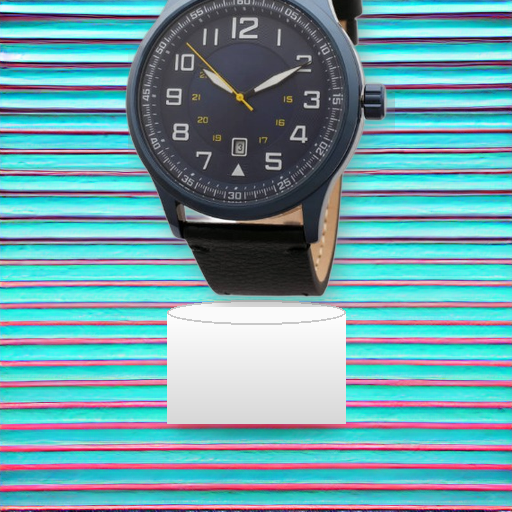

🎯 SUCCESS: Product placed on generated_cylindrical_pedestal platform!
